In [45]:
import pandas as pd
import re

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
tqdm.pandas()

In [46]:
file_name = "bitcoin_articles.csv"
df = pd.read_csv(file_name)
df.shape

(2500, 17)

In [47]:
df.head()

,article_id,title,author,published_date,link,clean_url,excerpt,summary,rights,article_rank,topic,country,language,authors,media,twitter_account,article_score
0,57a00c1140cbd3af79e77bf0e4e6af48,62% of Bitcoin Has Not Moved in a Year as Long...,Jamie McNeill,04-10-2022 17:15,https://www.business2community.com/crypto-news...,business2community.com,"Over the course of the last few years, there h...","Over the course of the last few years, there h...",business2community.com,1595,finance,US,en,Jamie McNeill,https://www.business2community.com/wp-content/...,@Jamie_DeFi,8.556426
1,21b48b3731c03466be3fac4be6c7dc67,The Orange Party Issue Playlist,Bitcoin Magazine,05-10-2022 21:17,https://bitcoinmagazine.com/culture/orange-par...,bitcoinmagazine.com,News Links: Russia Legalizing Bitcoin And Cryp...,Russia Legalizing Bitcoin And Crypto Is A Matt...,bitcoinmagazine.com,6284,news,US,en,Bitcoin Magazine,https://bitcoinmagazine.com/.image/t_share/MTk...,NaN,8.507881
2,77030740ee160ad68c25e4e63515dd77,How Many Bitcoins Are There?,AOL Staff,04-10-2022 21:44,https://www.gobankingrates.com/investing/crypt...,gobankingrates.com,Bitcoin has a maximum supply of 21 million. Ho...,Bitcoin has a maximum supply of 21 million. Ho...,aol.com,5044,news,US,en,"AOL Staff,David Granahan",https://s.yimg.com/ny/api/res/1.2/wPK4V8gjwjrD...,@AOL,8.483973
3,19285dde79599b6a9b4aa5a58805159b,Bitcoin 2008–2022: From Bouncing Baby To Troub...,Mark Hooson,03-10-2022 15:45,https://www.forbes.com/advisor/au/investing/bi...,forbes.com,"Conceived in 2008 and launched in 2009, bitcoi...","Conceived in 2008 and launched in 2009, bitcoi...",forbes.com,49,business,US,en,"Forbes Staff,Kevin Pratt,Mark Hooson,Sophie Venz",https://thumbor.forbes.com/thumbor/fit-in/x/ht...,NaN,8.466393
4,ad1822c7ff1bbd7e38f7f9dbdbce245f,"Bitcoin Lightning Network capacity strikes 5,0...",Joseph Hall,03-10-2022 12:09,https://cointelegraph.com/news/bitcoin-lightni...,cointelegraph.com,"First created in 2018, the Lighting Network ha...",Bear markets are for building out capacity on ...,cointelegraph.com,1696,news,US,en,Joseph Hall,https://images.cointelegraph.com/images/1200_a...,@cointelegraph,8.446906


In [48]:
df.columns

Index(['article_id', 'title', 'author', 'published_date', 'link', 'clean_url',
       'excerpt', 'summary', 'rights', 'article_rank', 'topic', 'country',
       'language', 'authors', 'media', 'twitter_account', 'article_score'],
      dtype='object')

In [49]:
data = df[['summary','title']]
data.head()

,summary,title
0,"Over the course of the last few years, there h...",62% of Bitcoin Has Not Moved in a Year as Long...
1,Russia Legalizing Bitcoin And Crypto Is A Matt...,The Orange Party Issue Playlist
2,Bitcoin has a maximum supply of 21 million. Ho...,How Many Bitcoins Are There?
3,"Conceived in 2008 and launched in 2009, bitcoi...",Bitcoin 2008–2022: From Bouncing Baby To Troub...
4,Bear markets are for building out capacity on ...,"Bitcoin Lightning Network capacity strikes 5,0..."


In [50]:
data.shape

(2500, 2)

## Preprocessing

In [51]:
data = data.dropna()

In [52]:
data.title.isna().sum()

0

In [53]:
data = data.copy()
data.summary = (
    data.summary
    .str.lower()
    .str.replace(r'\n',' ',regex=True)
    .str.replace(r'[^a-z0-9\%.\s]',' ',regex=True)
)
data.title = (
    data.title
    .str.lower()
    .str.replace(r'\n',' ',regex=True)
    .str.replace(r'[^a-z0-9\%.\s]',' ',regex=True)
)

data.head()

,summary,title
0,over the course of the last few years there h...,62% of bitcoin has not moved in a year as long...
1,russia legalizing bitcoin and crypto is a matt...,the orange party issue playlist
2,bitcoin has a maximum supply of 21 million. ho...,how many bitcoins are there
3,conceived in 2008 and launched in 2009 bitcoi...,bitcoin 2008 2022 from bouncing baby to troub...
4,bear markets are for building out capacity on ...,bitcoin lightning network capacity strikes 5 0...


In [54]:
data['combined'] = data['summary']+data['title']

In [55]:
data.to_csv("./dataset/cleaned_data.csv",index=False)

## Sentence Spliting

In [56]:
sentences = []
meta = []

for idx, row in data.iterrows():
    text = row["combined"]
    split_sents = re.split(r'(?<=[.!?])\s+', text)
    for sent in split_sents:
        if len(sent.strip()) > 10:
            sentences.append(sent.strip())
            meta.append(idx)

sent_df = pd.DataFrame({"sentence": sentences, "source_index": meta})
sent_df.head()


,sentence,source_index
0,over the course of the last few years there h...,0
1,the number of long term holders is always risi...,0
2,62% of bitcoin has not moved in a year the si...,0
3,as more and more bitcoin stays still there ar...,0
4,russia legalizing bitcoin and crypto is a matt...,1


## Sentence Embedings

In [57]:
from sentence_transformers import SentenceTransformer

In [58]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sent_df["sentence"].tolist(), show_progress_bar=True)

Batches: 100%|██████████| 300/300 [02:21<00:00,  2.12it/s]


In [59]:
from sklearn.cluster import KMeans

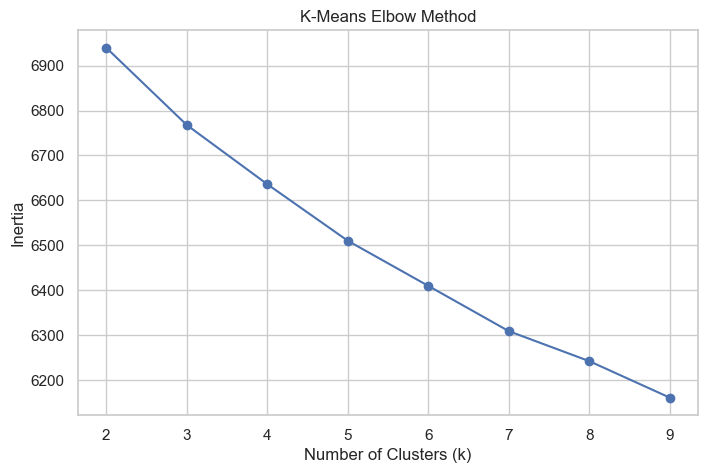

In [60]:
inertia = []
K = range(2, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embeddings)
    inertia.append(kmeans.inertia_)

# Plot elbow graph
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.title('K-Means Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

In [61]:
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
sent_df["cluster"] = kmeans.fit_predict(embeddings)
sent_df.head()

,sentence,source_index,cluster
0,over the course of the last few years there h...,0,1
1,the number of long term holders is always risi...,0,0
2,62% of bitcoin has not moved in a year the si...,0,0
3,as more and more bitcoin stays still there ar...,0,0
4,russia legalizing bitcoin and crypto is a matt...,1,1


In [62]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(sent_df["sentence"])

terms = vectorizer.get_feature_names_out()
for i in range(num_clusters):
    cluster_sentences = sent_df[sent_df["cluster"] == i]["sentence"]
    X_cluster = vectorizer.transform(cluster_sentences)
    sum_words = X_cluster.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    sorted_words = sorted(words_freq, key=lambda x: x[1], reverse=True)[:10]
    print(f"Cluster {i}: {[w for w, f in sorted_words]}")


Cluster 0: ['bitcoin', 'market', 'btc', 'traded', 'price', 'crypto', 'exchanges', 'day', 'dollar', '000']
Cluster 1: ['bitcoin', 'crypto', 'mining', 'btc', 'marketplace', 'hut', '2022', 'cryptocurrency', 'digital', 'new']
Cluster 2: ['digital', 'ledn', '2022', 'bitcoin', 'investment', 'asset', 'arxnovum', 'prnewswire', 'company', 'ceo']


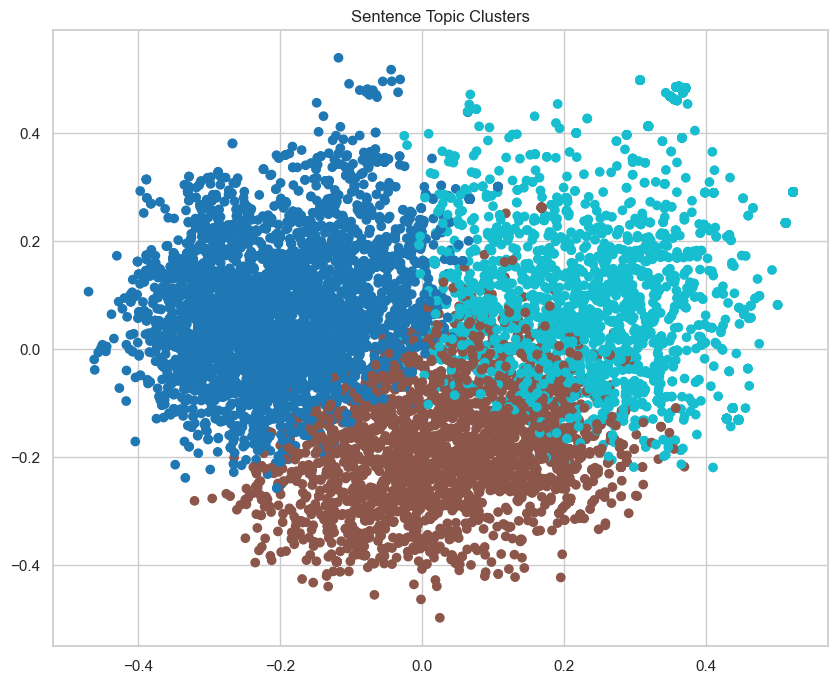

In [63]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(reduced[:, 0], reduced[:, 1], c=sent_df["cluster"], cmap='tab10')
plt.title("Sentence Topic Clusters")
plt.show()

In [64]:
sent_df.to_csv("./dataset/sentence_topic_clusters.csv", index=False)
